# Graphs Visualizations & Operations

In [68]:
import networkx as nx
import matplotlib.pyplot as plt


# Graph Visualization With Nodes Labels

Undirectional Graph

Is Weighted:  False
Is Directed:  False


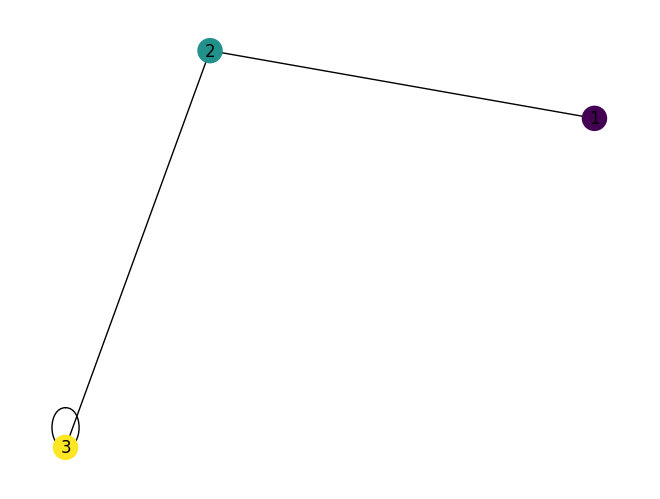

In [69]:
# Without weights
G = nx.Graph()
G.add_edge(1, 2)
G.add_edge(3, 2)
G.add_edge(3, 3) # Self looping
nx.draw(G, cmap=plt.get_cmap("viridis"), node_color=G, with_labels=True,)
print("Is Weighted: ", nx.is_weighted(G))
print("Is Directed: ", nx.is_directed(G))

In [70]:
# Representing graph in terms of matrix
nx.to_numpy_array(G)

array([[0., 1., 0.],
       [1., 0., 1.],
       [0., 1., 1.]])

Is Weighted:  True
Is Directed:  False


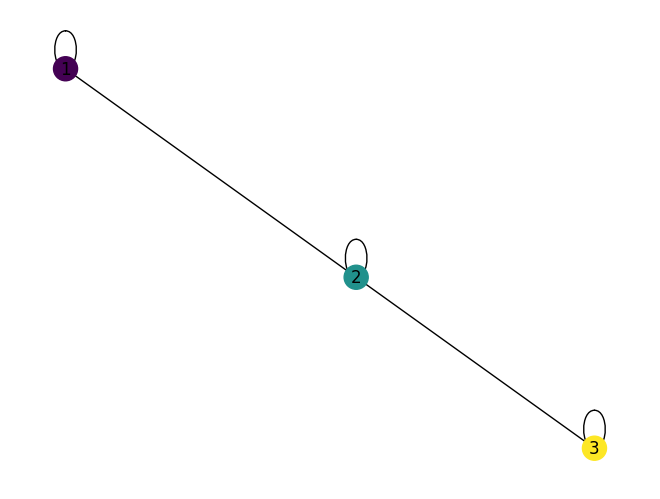

In [71]:
# With weights
G = nx.Graph()
G.add_edge(1, 2, weight=3)
G.add_edge(2, 3, weight=5)
# Self looping
G.add_edge(3, 3, weight=4)
G.add_edge(2, 2, weight=6)
G.add_edge(1, 1, weight=2)
nx.draw(G, cmap=plt.get_cmap("viridis"), node_color=G, with_labels=True,)
print("Is Weighted: ", nx.is_weighted(G)) # Returns 'True' when all of the edges in the graph are weighted.
print("Is Directed: ", nx.is_directed(G))

In [72]:
# Matrix representation
nx.to_numpy_array(G)

array([[2., 3., 0.],
       [3., 6., 5.],
       [0., 5., 4.]])

In [73]:
# Incidence matrix
I = nx.incidence_matrix(G)
print(I.todense())

[[1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [74]:
# Adjacency matrix
A = nx.adjacency_matrix(G)
print(A.todense())

[[2 3 0]
 [3 6 5]
 [0 5 4]]


In [75]:
# Diagonal values
A.diagonal()

array([2, 6, 4])

In [76]:
# Laplacian matrix i.e., L = D - A
L = nx.laplacian_matrix(G)
print(L.todense())

[[ 3 -3  0]
 [-3  8 -5]
 [ 0 -5  5]]


Directional Graph

Is Weighted:  True
Is Directed:  True


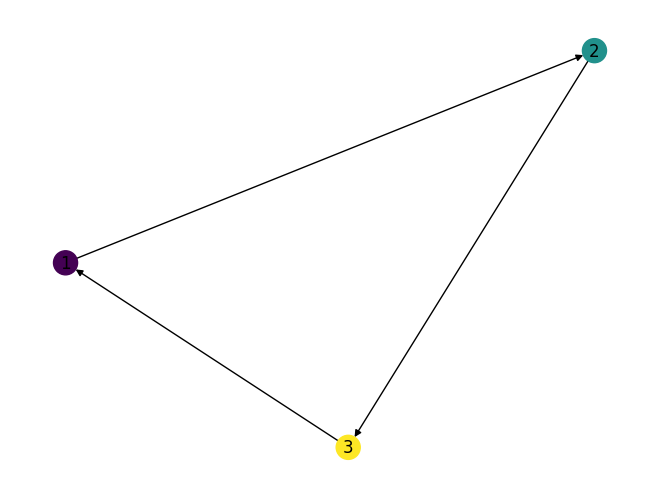

In [77]:
G = nx.DiGraph()
G.add_edge(1, 2, weight=2)
G.add_edge(2, 3, weight=4)
G.add_edge(3, 1, weight=10)

nx.draw(G, cmap=plt.get_cmap("viridis"), node_color=G, with_labels=True,)
print("Is Weighted: ", nx.is_weighted(G))
print("Is Directed: ", nx.is_directed(G))


In [78]:
# Incidence matrix
I = nx.incidence_matrix(G)
print(I.todense())

[[1. 0. 1.]
 [1. 1. 0.]
 [0. 1. 1.]]


In [79]:
# Diagonal values of I
I.diagonal()

array([1., 1., 1.])

In [80]:
# Adjacency matrix
A = nx.adjacency_matrix(G)
print(A.todense())

[[ 0  2  0]
 [ 0  0  4]
 [10  0  0]]


In [81]:
# Diagonal values
A.diagonal()

array([0, 0, 0])

In [82]:
# Laplacian matrix
L = nx.laplacian_matrix(G)
print(L.todense())

[[  2  -2   0]
 [  0   4  -4]
 [-10   0  10]]


# Graph Visualization With Node Classes

Is Weighted:  False
Is Directed:  False


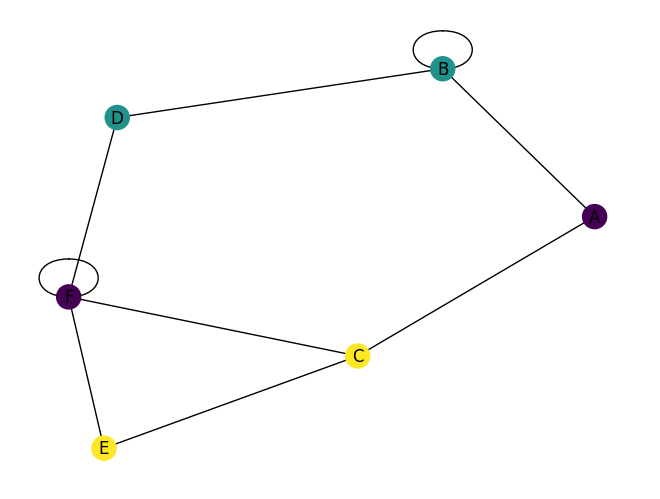

In [83]:
G = nx.Graph()
G.add_edges_from([("A", "B"), ("A", "C"), ("B", "D"), ("C", "E"), ("C", "F"), ("E", "F"), ("D", "F"), ("B", "B"), ("F", "F")])

val_map = {
    "A": 1.0,
    "B": 2.0,
    "C": 3.0,
    "D": 2.0,
    "E": 3.0,
    "F": 1.0
} # 'A' and 'F' belongs to same class as their values are same i.e., 1.0, likewise for other nodes.

values = [val_map.get(node, 0.25) for node in G.nodes()] # 'val_map.get(node, 0.25)' gets the mapped value of the node if it is in the dictionary, if it is not in the dictionary it returns the default value i.e., 0.25,

nx.draw(G, cmap=plt.get_cmap("viridis"), node_color=values, with_labels=True, font_color="black")

print("Is Weighted: ", nx.is_weighted(G))
print("Is Directed: ", nx.is_directed(G))

In [84]:
# Adjacency matrix
A = nx.adjacency_matrix(G)
print(A.todense())

[[0 1 1 0 0 0]
 [1 1 0 1 0 0]
 [1 0 0 0 1 1]
 [0 1 0 0 0 1]
 [0 0 1 0 0 1]
 [0 0 1 1 1 1]]


In [85]:
# Diagonal values
A.diagonal()

array([0, 1, 0, 0, 0, 1])

In [86]:
# Incidence matrix
I = nx.incidence_matrix(G)
print(I.todense())

[[1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 1. 1. 0.]]


In [87]:
# Laplacian matrix
L = nx.laplacian_matrix(G)
print(L.todense())

[[ 2 -1 -1  0  0  0]
 [-1  2  0 -1  0  0]
 [-1  0  3  0 -1 -1]
 [ 0 -1  0  2  0 -1]
 [ 0  0 -1  0  2 -1]
 [ 0  0 -1 -1 -1  3]]


# Graph Visualization With Nodes & Edges Labels

In [88]:
# Edges & its labels
edge_labels = {
    ("A", "B"): "e1",
    ("A", "C"): "e2",
    ("B", "D"): "e3",
    ("C", "E"): "e4",
    ("C", "F"): "e5",
    ("E", "F"): "e6",
    ("D", "F"): "e7",
    ("B", "B"): "e8",
    ("F", "F"): "e9"
}

all_edges = [("A", "B"), ("A", "C"), ("B", "D"), ("C", "E"), ("C", "F"), ("E", "F"), ("D", "F"), ("B", "B"), ("F", "F")]

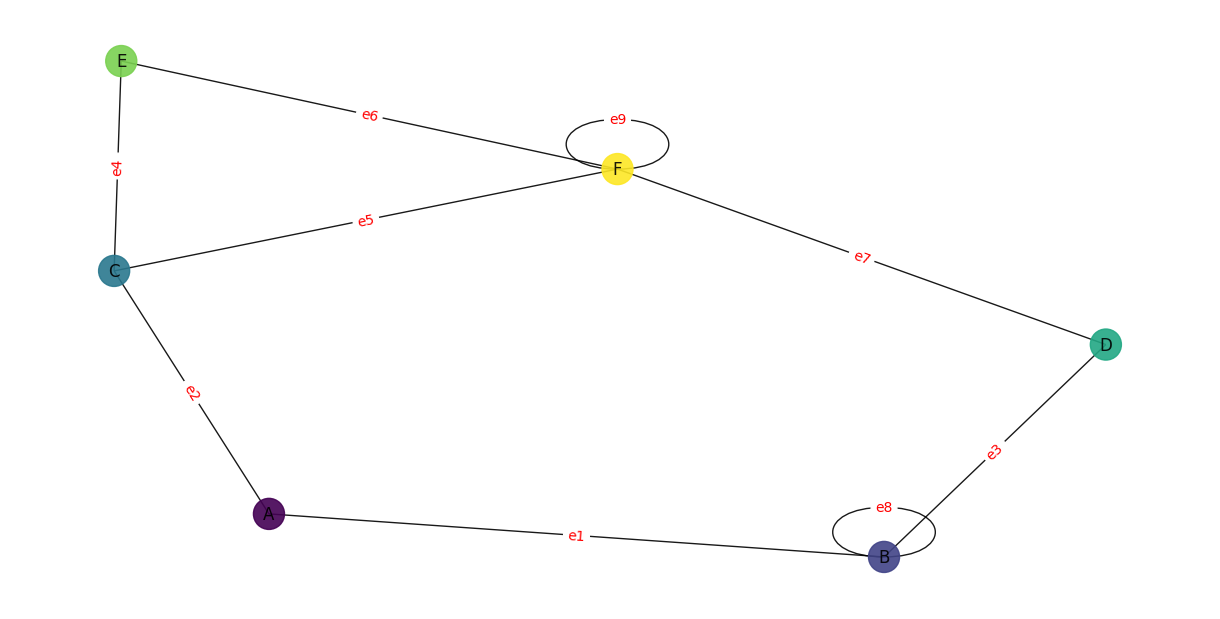

Is Weighted:  False
Is Directed:  False
Number of nodes:  6
Number of edges:  9


In [89]:
G = nx.Graph()
G.add_edges_from(all_edges)

val_map = {
    "A": 1.0,
    "B": 2.0,
    "C": 3.0,
    "D": 4.0,
    "E": 5.0,
    "F": 6.0
}

values = [val_map.get(node, 0.25) for node in G.nodes]

pos = nx.spring_layout(G)
plt.figure(figsize=(12, 6)) # width = 12 inches & height = 6 inches

nx.draw(G, pos, edge_color="black", width=1, linewidths=1, node_size=500, node_color=values, alpha=0.9, labels={node:node for node in G.nodes()})
# 'linewidth=1' sets the thicknes of borders around the circular nodes to 1.
# 'node_size=500' sets the size of the nodes to 500.
# 'alpha=0.9' sets the tranparency of the nodes and edges i.e., 90% opaque and 10% transparent.
# 'labels={"A": "A", "B": "B", ...}' to print name of each node on to the node circle.

nx.draw_networkx_edge_labels(G.to_directed(), pos, edge_labels=edge_labels, font_color="red")

plt.axis("off") # Hides the x & y axis and grid lines
plt.show()

print("Is Weighted: ", nx.is_weighted(G))
print("Is Directed: ", nx.is_directed(G))
print("Number of nodes: ", G.number_of_nodes())
print("Number of edges: ", G.number_of_edges())


In [90]:
nx.to_numpy_array(G.to_directed())

array([[0., 1., 1., 0., 0., 0.],
       [1., 1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1., 1.],
       [0., 1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 1., 1.]])

In [91]:
# Adjacency matrix
A = nx.adjacency_matrix(G)
print(A.todense())

[[0 1 1 0 0 0]
 [1 1 0 1 0 0]
 [1 0 0 0 1 1]
 [0 1 0 0 0 1]
 [0 0 1 0 0 1]
 [0 0 1 1 1 1]]


In [92]:
A.diagonal()

array([0, 1, 0, 0, 0, 1])

In [93]:
# Incidence matrix
I = nx.incidence_matrix(G)
print(I.todense())

[[1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 1. 1. 0.]]


In [94]:
# Node degree
G.degree()

DegreeView({'A': 2, 'B': 4, 'C': 3, 'D': 2, 'E': 2, 'F': 5})

In [95]:
# Laplacian matrix
L = nx.laplacian_matrix(G)
print(L.todense())

[[ 2 -1 -1  0  0  0]
 [-1  2  0 -1  0  0]
 [-1  0  3  0 -1 -1]
 [ 0 -1  0  2  0 -1]
 [ 0  0 -1  0  2 -1]
 [ 0  0 -1 -1 -1  3]]


In [96]:
# Adjacency list
for line in nx.generate_adjlist(G):
  print(line)

A B C
B D B
C E F
D F
E F
F F


# Listing All Adjacent Nodes

In [97]:
# Listing adjacent nodes in a proper format
def get_adjacent_list_with_all_edges(graph):
  for s, neighbors in graph.adjacency():
    line = str(s) + " : "
    for t, data in neighbors.items():
      line += str(t) + " - "
    yield line[: -len(" ")]

for line in get_adjacent_list_with_all_edges(G):
  print(line)

A : B - C -
B : A - D - B -
C : A - E - F -
D : B - F -
E : C - F -
F : C - E - D - F -


# Bag Of Nodes

Aggregation of node level features using some mathematical approach i.e., taking the mean of the node degrees or histogram of the edge connections.

# Graph Walking - Random Walk

Graph walking is a method of traversing the graph through the connected nodes.

Random walk is a technique to extract sequences from a graph from any random node perspective. It is used to train the skip-gram model to learn node embeddings.

In [98]:
# Function for random walk in a graph.
import random
def get_randomwalk(graph, node, path_length):
  random_walk = [node]

  for i in range(path_length):
    temp = list(graph.neighbors(node))
    temp = list(set(temp) - set(random_walk)) # e.g., list(set([1, 2, 2, 3]) - set([3, 4, 5])) = list({1, 2, 3} - {3, 4, 5}) = [1, 2, 4, 5]
    if len(temp) == 0:
      break

    random_node = random.choice(temp)
    random_walk.append(random_node)
    node = random_node

  return random_walk

In [99]:
get_randomwalk(G, "C", 5)

['C', 'F', 'D', 'B', 'A']

In [100]:
from tqdm import tqdm # 'tqdm' comes from Arabic word 'taqaddum' means 'progress' this library shows the progress bar of the running process.
all_nodes = list(G.nodes())

random_walk = []
for n in tqdm(all_nodes):
  for i in range(2):
    random_walk.append(get_randomwalk(G, n, i))
    print("\nNeighbors of {}: ".format(n), random_walk)

   # Amount of sequence
print("\nAmount of sequences: ", len(random_walk))

100%|██████████| 6/6 [00:00<00:00, 6358.22it/s]


Neighbors of A:  [['A']]

Neighbors of A:  [['A'], ['A', 'C']]

Neighbors of B:  [['A'], ['A', 'C'], ['B']]

Neighbors of B:  [['A'], ['A', 'C'], ['B'], ['B', 'A']]

Neighbors of C:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C']]

Neighbors of C:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A']]

Neighbors of D:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A'], ['D']]

Neighbors of D:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A'], ['D'], ['D', 'B']]

Neighbors of E:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A'], ['D'], ['D', 'B'], ['E']]

Neighbors of E:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A'], ['D'], ['D', 'B'], ['E'], ['E', 'F']]

Neighbors of F:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A'], ['D'], ['D', 'B'], ['E'], ['E', 'F'], ['F']]

Neighbors of F:  [['A'], ['A', 'C'], ['B'], ['B', 'A'], ['C'], ['C', 'A'], ['D'], ['D', 'B'], ['E'], ['E', 'F'], ['F'], ['F', 'D']]

Amount of sequences:  12
